In [30]:
from pathlib import Path
from collections import Counter

import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mne.datasets import eegbci

### Find recordings

This finds EDF files one subject folder below the data directory. The sorted result contains subjects S001–S005 and three runs each (04, 08, 12): **15 recordings**.

For these runs, T1 means imagined left-fist movement, T2 imagined right-fist movement, and T0 rest. This interpretation changes for other run types. [PhysioNet task definitions](https://physionet.org/content/eegmmidb/1.0.0/)

In [31]:
DATA_DIR = Path(
    "../data/raw/eegbci/MNE-eegbci-data/files/eegmmidb/1.0.0"
)

files = sorted(DATA_DIR.glob("S*/S*R*.edf"))

print(f"Found {len(files)} recordings")
for path in files:
    print(path.name)

Found 15 recordings
S001R04.edf
S001R08.edf
S001R12.edf
S002R04.edf
S002R08.edf
S002R12.edf
S003R04.edf
S003R08.edf
S003R12.edf
S004R04.edf
S004R08.edf
S004R12.edf
S005R04.edf
S005R08.edf
S005R12.edf


### Inspect one recording

This loads the entire first EDF into memory, standardizes names such as `C3..` to `C3`, assigns standard electrode coordinates, and immediately subtracts the average EEG signal from every channel. The reference is an instantaneous spatial operation; the montage only supplies geometry. Neither removes artifacts by itself.

The printed `64 × 20000` means 64 channels with 20,000 samples each: 125 seconds at 160 Hz. Thirty annotations comprise 15 rest intervals and 15 task intervals (eight left, seven right). These are annotation intervals, not 30 imagery trials.

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>
['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']


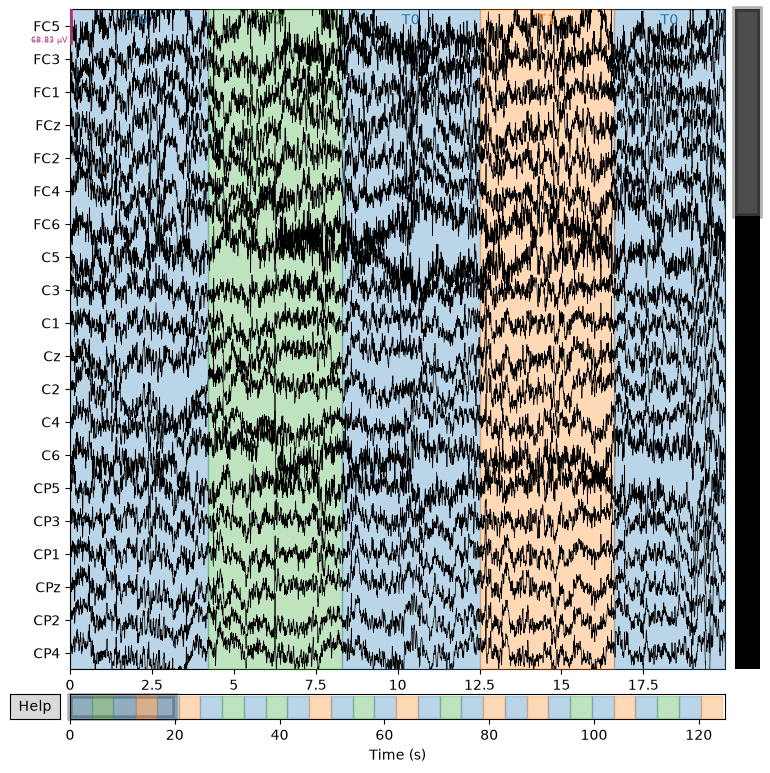

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/opt/anaconda3/envs/eeg-mi/lib/python3.11/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


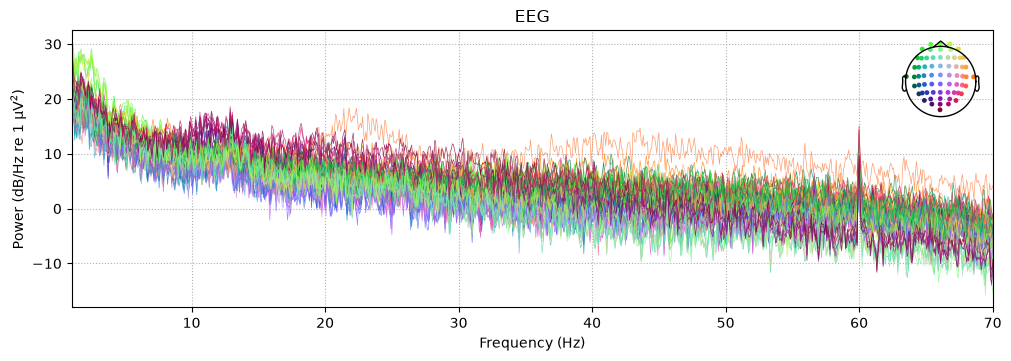

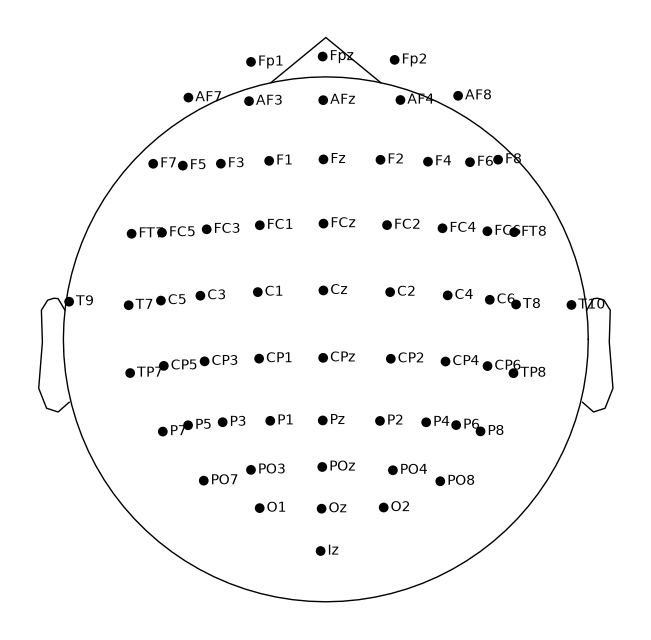

In [32]:
def inspect_recording(path) -> None:
    raw = mne.io.read_raw_edf(
        path,
        preload=True,
        verbose="ERROR"
    )

    eegbci.standardize(raw)
    raw.set_montage("standard_1005")
    raw.set_eeg_reference(
        "average",
        projection=False,
        verbose="ERROR"
    )

    print(raw)
    print(raw.annotations)
    print(raw.ch_names)

    raw.plot(
    duration=20,
    n_channels=20,
    scalings="auto",
)

    raw.compute_psd(
        fmin=1,
        fmax=70,
    ).plot()

    _ = raw.plot_sensors(show_names=True)

    return None

inspect_recording(files[0])

#### Reading the three inspection figures

**Raw traces**: 

The horizontal axis is time in seconds, with each row representing one electrode. The displayed scale bar is approximately 68.83 µV under automatic scaling. The colored bands mark T0 rest (blue), T1 left (green), and T2 right (orange) annotations. The bottom strip summarizes the full recording, which this specific snapshot represents the first 20 seconds and only 20 out of 64 channels.

**Power spectral density (PSD)**: 

The horizonal axis is frequency (1-70 Hz), and the vertical axis is spectral power in dB relative to µV²/Hz. Each colored trace represents a channel (refer to the schematic on the top right). The power faces a downard trend as frequency rises, with a modest bump around 10-15 Hz, a narrow peak near 60 Hz, and one elevated trace approximately around 20-25 and 35-55 Hz with the even (right) frontal region.

**Sensor map**:

Top-down schematic with each point representing an electrode or region of the brain.

### Preprocess and extract imagery trials (one recording)

In [33]:
def make_epochs_tuned(path) -> mne.Epochs:
    raw = mne.io.read_raw_edf(
        path,
        preload=True,
        verbose="ERROR"
    )
    eegbci.standardize(raw)
    raw.set_montage("standard_1005")
    raw.set_eeg_reference(
        "average",
        projection=False,
        verbose="ERROR"
    )
    raw.filter(
        l_freq=8,
        h_freq=30,
        fir_design="firwin",
        verbose="ERROR"
    )
    events, _ = mne.events_from_annotations(
    raw,
    event_id={
        "T1": 1,
        "T2": 2 
    },
    verbose="ERROR"
    )
    epochs = mne.Epochs(
        raw,
        events,
        event_id={
            "left_hand": 1,
            "right_hand": 2,
        },
        tmin=0.5,
        tmax=3.5,
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose="ERROR"
    )
    subject = int(path.parent.name.removeprefix("S"))
    run = int(path.stem.split("R")[-1])
    epochs.metadata = pd.DataFrame({
        "subject": [subject] * len(epochs),
        "run": [run] * len(epochs),
    })
    print(raw)
    print(raw.annotations)
    print(raw.ch_names)
    return epochs

epochs = make_epochs_tuned(files[0]) 
print(epochs)

Adding metadata with 2 columns
<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>
['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']
<Epochs | 15 events (all good), 0.5 – 3.5 s (baseline off), ~3.6 MiB, data loaded, with metadata,
 'left_hand': 8
 'right_hand': 7>


In [34]:
epoch_sets = [make_epochs_tuned(path) for path in files]
epochs = mne.concatenate_epochs(epoch_sets)
epochs

Adding metadata with 2 columns
<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>
['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']
Adding metadata with 2 columns
<RawEDF | S001R08.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>
['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T

/var/folders/kg/syn5dsfn40l0n2qfhr_8whqh0000gn/T/ipykernel_90304/967584946.py:2: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(epoch_sets)


<EpochsArray | 225 events (all good), 0.5 – 3.5 s (baseline off), ~52.9 MiB, data loaded, with metadata,
 'left_hand': 113
 'right_hand': 112>

## Modeling

### Construct inputs

`X` contains EEG in MNE's internal units of volts, with shape `(225, 64, 481)` = trials × channels × time samples. 

`y` contains integer labels 1 and 2. `subjects` and `runs` identify which rows belong together for splitting

In [35]:
X = epochs.get_data(copy=True)
y = epochs.events[:, -1]

subjects = epochs.metadata["subject"].to_numpy()
runs = epochs.metadata["run"].to_numpy()

print("EEG array:", X.shape)
print("Labels:", np.unique(y, return_counts=True))

EEG array: (225, 64, 481)
Labels: (array([1, 2]), array([113, 112]))


### Checking class balance
- 45 trials per person
- 113 total left and 112 total right; no oversampling

In [36]:
trial_table = epochs.metadata.copy()
trial_table["condition"] = np.where(
    y == 1,
    "left_hand",
    "right_hand",
)

pd.crosstab(
    trial_table["subject"],
    trial_table["condition"],
    margins=True,
)

condition,left_hand,right_hand,All
subject,,,
1,23,22,45
2,23,22,45
3,23,22,45
4,23,22,45
5,21,24,45
All,113,112,225


### Import model

In [37]:
from mne.decoding import CSP, get_spatial_filter_from_estimator
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score, ShuffleSplit
from sklearn.pipeline import make_pipeline

### CSP (Common Spatial Pattern) and LDA (Linear Discriminant Analysis) Baseline Model

CSP learns spatial filters from labeled training EEG, then converts each trial into four log-power features, similar to PCA for dimensionality reduction.

In [38]:
model = make_pipeline(
        CSP(4,reg=None, log=True, norm_trace=False),
        LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"),
        )

#### Evaluate model from the same person
For each person, the model trains on two runs (30 trials), tests the remaining run (15 trials), and rotates through three held-out runs. This is the correct grouping for within-person, across-run development performance. It does not test a new person or establish performance on another day.

Balanced accuracy gives equal weight to the recall of left and right imagery. With two classes, 50% is the probability reference.

In [39]:
within_subject_scores = dict()

for subject in np.unique(subjects):
    selected = subjects == subject

    scores = cross_val_score(
        model,
        X[selected],
        y[selected],
        groups=runs[selected],
        cv=LeaveOneGroupOut(),
        scoring="balanced_accuracy",
    )
    within_subject_scores[subject] = [scores, scores.mean()]

within_subject_scores

Computing rank from data with rank=None
    Using tolerance 0.0001 (2.2e-16 eps * 64 dim * 7e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.00011 (2.2e-16 eps * 64 dim * 7.6e+09  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.000

{np.int64(1): [array([0.5       , 0.66071429, 0.61607143]),
  np.float64(0.5922619047619048)],
 np.int64(2): [array([0.92857143, 1.        , 0.92857143]),
  np.float64(0.9523809523809524)],
 np.int64(3): [array([0.8125    , 0.5625    , 0.49107143]),
  np.float64(0.6220238095238095)],
 np.int64(4): [array([0.5       , 0.625     , 0.61607143]),
  np.float64(0.5803571428571429)],
 np.int64(5): [array([0.4375    , 0.54464286, 0.53571429]),
  np.float64(0.5059523809523809)]}

### Interpretation of within-person results

| Person | Mean balanced accuracy |
|---|---:|
| 1 | 59.2% |
| 2 | 95.2% |
| 3 | 62.2% |
| 4 | 58.0% |
| 5 | 50.6% |

Mean: 65.1%; median: 59.2%

In [40]:
subject_cv = LeaveOneGroupOut()

cross_subject_scores = cross_val_score(
    model,
    X,
    y,
    groups=subjects,
    cv=subject_cv,
    scoring="balanced_accuracy",
)

print("Held-out-subject scores:", cross_subject_scores)
print("Mean:", cross_subject_scores.mean())
print("Standard deviation:", cross_subject_scores.std())

Computing rank from data with rank=None
    Using tolerance 0.00018 (2.2e-16 eps * 64 dim * 1.2e+10  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.0002 (2.2e-16 eps * 64 dim * 1.4e+10  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)
Computing rank from data with rank=None
    Using tolerance 0.0

#### Interpretation of cross-person results
Held-out-subject scores are 42.7%, 50.0%, 41.4%, 52.5%, and 50.0%, with a mean of 47.3% and 4.4% standard deviation. The current pipeline does not demonstrate useful unseen-person generalization.

### Inspect pooled CSP fit
Fits standalone global CSP on all 225 labeled trials, then visualizes the fitted decomposition.

In [41]:
lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
csp = CSP(4,reg=None, log=True, norm_trace=False)

Computing rank from data with rank=None
    Using tolerance 0.00022 (2.2e-16 eps * 64 dim * 1.5e+10  max singular value)
    Estimated rank (data): 63
    data: rank 63 computed from 64 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
    Setting small data eigenvalues to zero (without PCA)


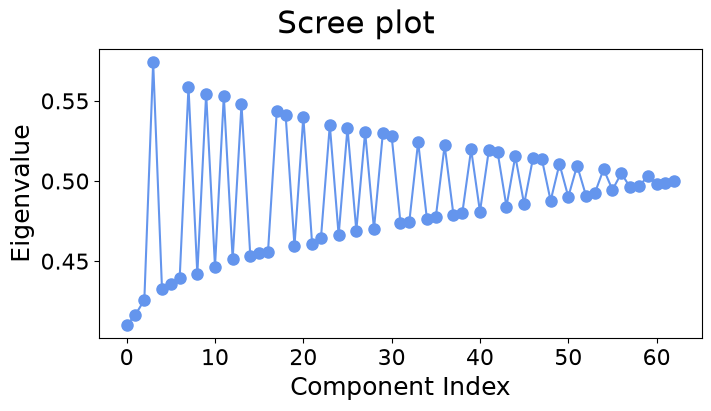

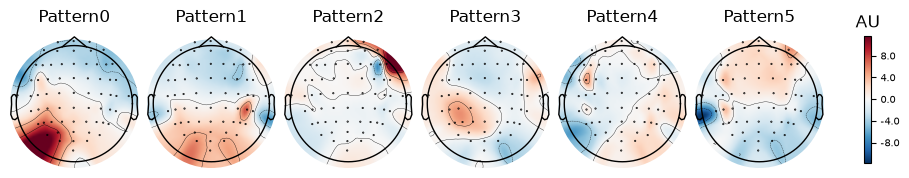

In [42]:
csp.fit_transform(X, y)
spf = get_spatial_filter_from_estimator(csp, info=epochs.info)
spf.plot_scree()
_ = spf.plot_patterns(components=np.arange(6))

#### Interpretating CSP figures

**CSP scree plot**:

The x-axis indexes spatial components, while the y-axis shows generalized eigenvalues. The value represents a component's variance for the first class relative to its combined variance across both classes. Values near 0.5 indicate similar class variances, while values further from 0.5 indicate a large in-sample contrast.